# Radiance-Field ERP — Cache Visualisation

Loads pre-computed `.npy` caches from `data/processed/` and produces
publication-quality figures characterising the 8-channel radiance-field
ERP representation.

**No PLY files or GPU required.** All plots read from the ERP cache.

| # | Section | Visualisation |
|---|---------|---------------|
| 1 | Shell Strip | All 8 density shells individually |
| 2 | MIP & Depth | Max-intensity projection and depth map |
| 3 | Radial Depth Profile | Density vs shell at 4 azimuths |
| 4 | Polar Density | Azimuth-averaged radial density |
| 5 | Onion Cross-Section | Meridian slices at 4 azimuths |
| 6 | Per-Shell Statistics | Violin plots and box plots |
| 7 | Inter-Shell Correlation | Pearson correlation heatmap |
| 8 | Radial Signatures | Cross-class mean shell profiles |
| 9 | Latitude Density + SWHDC | Latitude-resolved density with SWHDC weights |
| 10 | Feature Embedding | PCA + t-SNE of shell features |
| 11 | Class Mean Montage | Per-pixel average density per class |
| 12 | Sparsity & Energy | Shell sparsity and energy distribution |

---
## Imports and paths

In [23]:
import sys
import warnings
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.colors as mcolors
from matplotlib.ticker import MaxNLocator
from scipy.ndimage import gaussian_filter
from scipy.stats import pearsonr
import seaborn as sns

warnings.filterwarnings('ignore')

PROJECT_ROOT = Path('..').resolve()
sys.path.insert(0, str(PROJECT_ROOT))

from src.preprocessing.dataset import MODELNET10_CATEGORIES

plt.rcParams.update({
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif'],
    'font.size': 11,
    'axes.titlesize': 12,
    'axes.titleweight': 'normal',
    'axes.labelsize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'mathtext.fontset': 'cm',
})

FIG_DIR = PROJECT_ROOT / 'experiments' / 'figures' / 'erp_viz'
FIG_DIR.mkdir(parents=True, exist_ok=True)
print(f'Figures → {FIG_DIR}')

Figures → C:\DEV_ENV\source\UFRGS\TCC\gs-erp-3d-classification\experiments\figures\erp_viz


---
## Configuration — point to your cache

In [24]:
CACHE_CANDIDATES = [
    PROJECT_ROOT / 'data' / 'processed' / 'modelnet10' / 'radiance_field',
    PROJECT_ROOT / 'data' / 'processed' / 'modelnet40' / 'radiance_field',
]

CACHE_ROOT = next((c for c in CACHE_CANDIDATES if c.exists()), None)
if CACHE_ROOT is None:
    raise FileNotFoundError(
        'No ERP cache found.  Run the preprocessing script first.'
    )

param_dirs = [d for d in sorted(CACHE_ROOT.iterdir()) if d.is_dir()]
if not param_dirs:
    raise FileNotFoundError(f'No params subdirectory found under {CACHE_ROOT}')
PARAM_DIR = param_dirs[0]
print(f'Cache root    : {CACHE_ROOT.name}')
print(f'Cache params  : {PARAM_DIR.name}')

# Detect N_SHELLS from the params dir name (ns<N>_...)
import re as _re
_ns_match = _re.search(r'ns(\d+)', PARAM_DIR.name)
N_SHELLS = int(_ns_match.group(1)) if _ns_match else 8
print(f'N_SHELLS      : {N_SHELLS}')

# Discover cached classes
ALL_CLASSES = sorted([d.name for d in PARAM_DIR.iterdir() if d.is_dir()])

# Helpers
def list_npys(category: str, split: str = 'train') -> list[Path]:
    d = PARAM_DIR / category / split
    return sorted(d.glob('*.npy')) if d.exists() else []

def load_erp(path: Path) -> np.ndarray | None:
    """Load .npy file with error handling for corrupted files."""
    try:
        arr = np.load(path)
        if arr.size == 0:
            print(f'  ⚠ Skipping empty file: {path.name}')
            return None
        return arr.astype(np.float32)
    except (EOFError, OSError, ValueError) as e:
        print(f'  ⚠ Skipping corrupted file {path.name}: {type(e).__name__}')
        return None

def normalise(arr: np.ndarray) -> np.ndarray:
    lo, hi = arr.min(), arr.max()
    return (arr - lo) / (hi - lo + 1e-12)

def load_class_erps(cls: str, split: str = 'train', max_n: int | None = None) -> list[np.ndarray]:
    """Load all .npy files for a class, silently skipping corrupted ones."""
    paths = list_npys(cls, split)
    if max_n is not None:
        paths = paths[:max_n]
    loaded = []
    for p in paths:
        erp = load_erp(p)
        if erp is not None:
            loaded.append(erp)
    return loaded

# Consistent class colours
_tab10 = plt.cm.tab10.colors
CLASS_COLORS = {cls: _tab10[i % 10] for i, cls in enumerate(ALL_CLASSES)}
STAT_CLASSES = [cls for cls in ALL_CLASSES if len(list_npys(cls, 'train')) >= 20]
SHELL_COLORS = plt.cm.plasma(np.linspace(0.15, 0.9, N_SHELLS))

# Pick a reference sample
FOCUS_CLASS = 'desk' if 'desk' in ALL_CLASSES else ALL_CLASSES[0]
sample_paths = list_npys(FOCUS_CLASS, 'train')
if not sample_paths:
    FOCUS_CLASS = next((c for c in ALL_CLASSES if list_npys(c)), None)
    sample_paths = list_npys(FOCUS_CLASS, 'train')
if not sample_paths:
    raise FileNotFoundError('No cached .npy files found.')

REF_PATH = sample_paths[0]
erp = load_erp(REF_PATH)
if erp is None:
    # Find first valid file
    for cls in ALL_CLASSES:
        for p in list_npys(cls, 'train'):
            erp = load_erp(p)
            if erp is not None:
                REF_PATH = p
                FOCUS_CLASS = cls
                break
        if erp is not None:
            break

H, W = erp.shape[1], erp.shape[2]

# Degree-based tick helpers (reused across sections)
az_ticks = np.linspace(0, W, 5)
az_labels = ['0°', '90°', '180°', '270°', '360°']
el_ticks = np.linspace(0, H, 3)
el_labels = ['+90°', '0°', '−90°']

print(f'Reference class  : {FOCUS_CLASS}')
print(f'Sample file      : {REF_PATH.name}')
print(f'ERP shape        : {erp.shape}   (N_shells={erp.shape[0]}, H={H}, W={W})')
print(f'Value range      : [{erp.min():.4f}, {erp.max():.4f}]')
print(f'Available classes : {ALL_CLASSES}')
print(f'Stat classes     : {STAT_CLASSES}')

Cache root    : radiance_field
Cache params  : ns8_H256_W512_c3.0_p5.0-95.0
N_SHELLS      : 8
Reference class  : desk
Sample file      : desk_0001.npy
ERP shape        : (8, 256, 512)   (N_shells=8, H=256, W=512)
Value range      : [0.0000, 10.6838]
Available classes : ['bathtub', 'bed', 'chair', 'desk', 'dresser', 'monitor', 'night_stand', 'sofa', 'table', 'toilet']
Stat classes     : []


---
## Pre-compute per-class statistics

In [25]:
print('Pre-computing per-class statistics ...')

class_shell_profiles = {}   # cls -> (N, 8)
class_lat_profiles   = {}   # cls -> (N, H)
class_features       = {}   # cls -> (N, 48)
class_sparsity       = {}   # cls -> (N, 8)
class_energy_frac    = {}   # cls -> (N, 8)

for cls in ALL_CLASSES:
    erps = load_class_erps(cls, 'train', max_n=80)
    if not erps:
        print(f'  {cls:15s}: ⊘ no valid samples')
        continue

    shell_profiles, lat_profiles, features, sparsity, energy_frac = [], [], [], [], []

    for e in erps:
        shell_profiles.append(e.mean(axis=(1, 2)))
        lat_profiles.append(e.mean(axis=(0, 2)))
        sparsity.append(np.array([(e[s] < 1e-6).mean() for s in range(N_SHELLS)]))
        shell_sums = e.sum(axis=(1, 2))
        total = shell_sums.sum()
        energy_frac.append(shell_sums / (total + 1e-12))
        feat = []
        for s in range(N_SHELLS):
            v = e[s].ravel()
            feat.extend([v.mean(), v.std(),
                         np.percentile(v, 25), np.percentile(v, 50),
                         np.percentile(v, 75), (v < 1e-6).mean()])
        features.append(feat)

    class_shell_profiles[cls] = np.array(shell_profiles)
    class_lat_profiles[cls]   = np.array(lat_profiles)
    class_features[cls]       = np.array(features)
    class_sparsity[cls]       = np.array(sparsity)
    class_energy_frac[cls]    = np.array(energy_frac)
    print(f'  {cls:15s}: {len(erps):4d} samples')

print(f'\nSTAT_CLASSES ({len(STAT_CLASSES)}): {STAT_CLASSES}')

Pre-computing per-class statistics ...
  bathtub        :   10 samples
  bed            :   10 samples
  chair          :   10 samples
  desk           :   10 samples
  dresser        :   10 samples
  monitor        :   10 samples
  night_stand    :   10 samples
  sofa           :   10 samples
  table          :   10 samples
  toilet         :   10 samples

STAT_CLASSES (0): []


---
## Section 1 — Shell Strip: all 8 density maps

Each panel shows one ERP channel (one concentric shell). Shell 1 is the
innermost (smallest radius) and Shell 8 is the outermost.

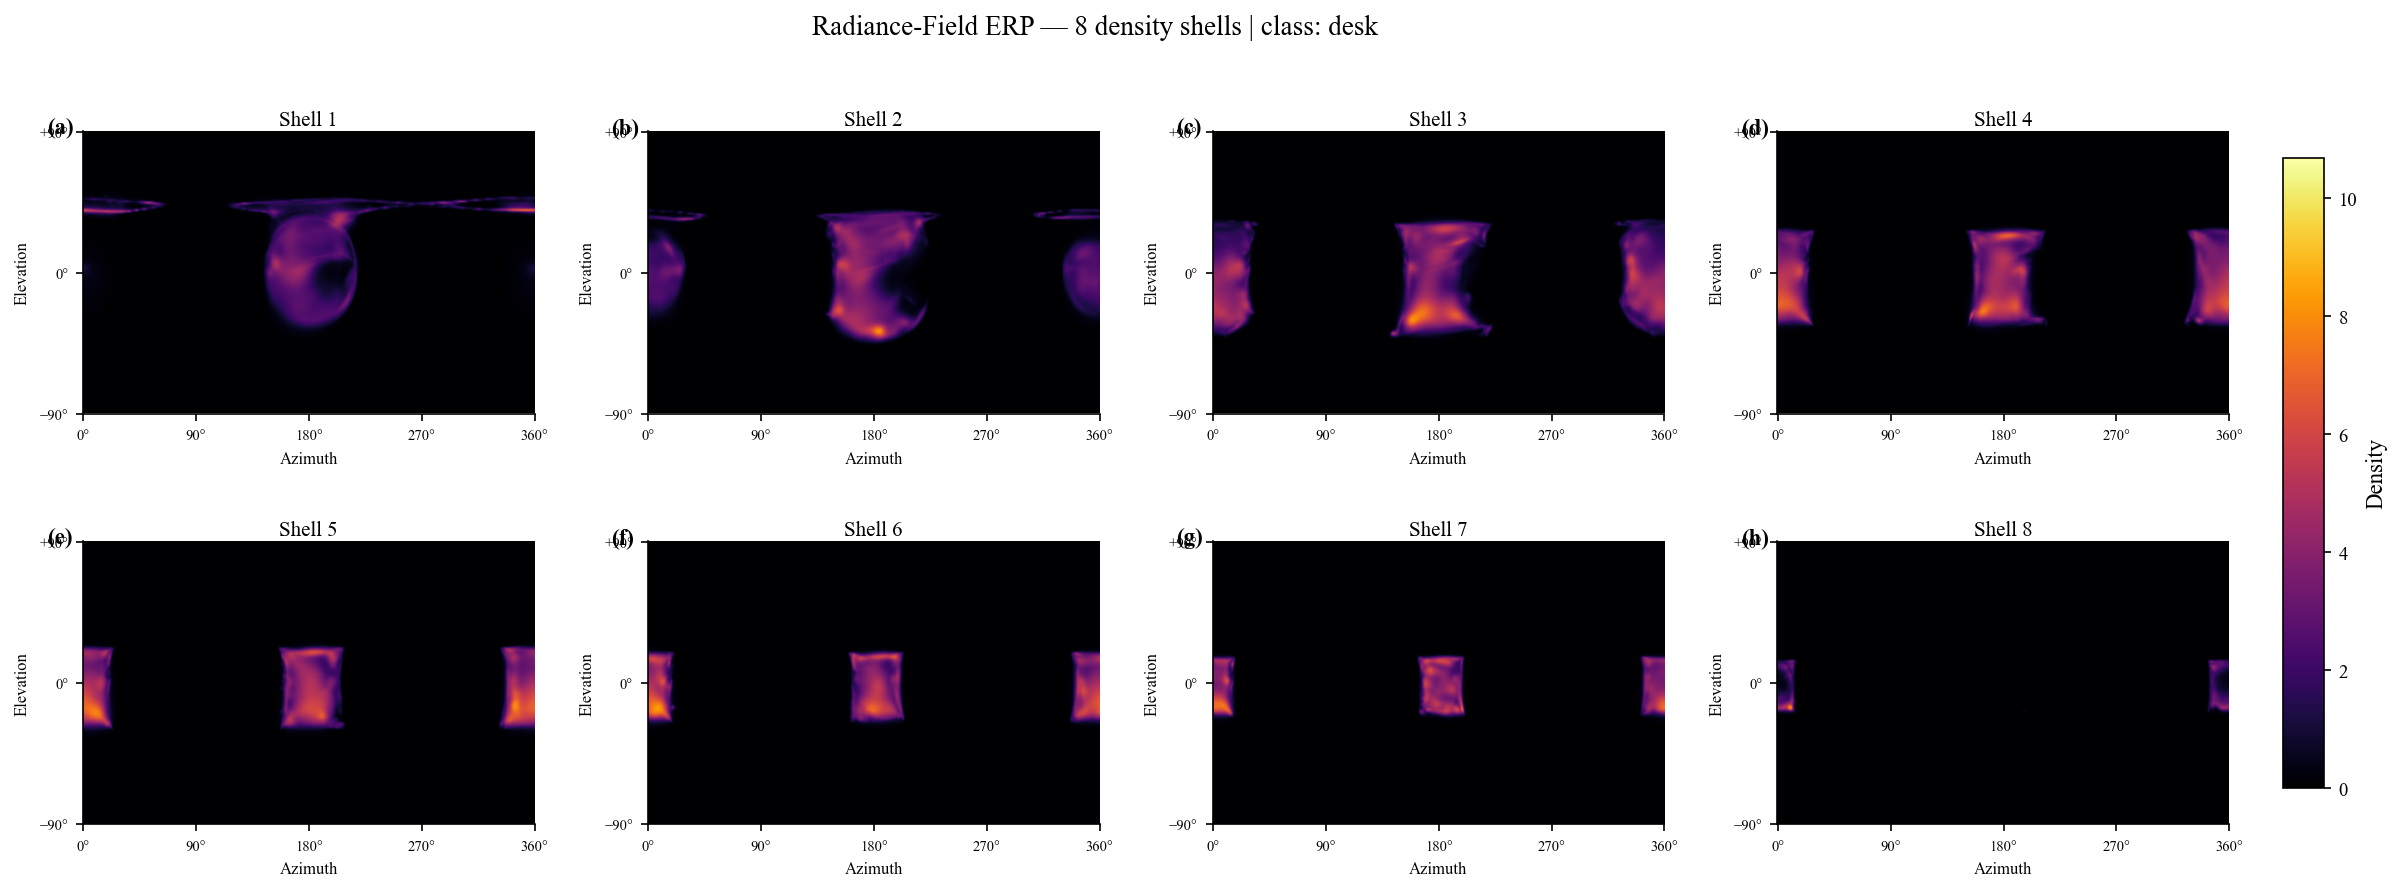

In [26]:
vmin, vmax = 0, erp.max()

fig, axes = plt.subplots(2, 4, figsize=(18, 6),
                          gridspec_kw={'hspace': 0.45, 'wspace': 0.25})

panel_labels = 'abcdefgh'

for s, ax in enumerate(axes.flat):
    d = gaussian_filter(erp[s], sigma=0.8)
    im = ax.imshow(d, cmap='inferno', aspect='auto', interpolation='bilinear',
                   vmin=vmin, vmax=vmax)
    ax.set_title(f'Shell {s + 1}', fontsize=10, pad=3)
    ax.set_xticks(az_ticks)
    ax.set_xticklabels(az_labels, fontsize=7)
    ax.set_yticks(el_ticks)
    ax.set_yticklabels(el_labels, fontsize=7)
    ax.set_xlabel('Azimuth', fontsize=8)
    ax.set_ylabel('Elevation', fontsize=8)
    ax.text(-0.08, 1.05, f'({panel_labels[s]})', transform=ax.transAxes,
            fontsize=11, fontweight='bold', va='top')

# Shared colorbar
fig.subplots_adjust(right=0.92)
cbar_ax = fig.add_axes([0.94, 0.15, 0.015, 0.7])
fig.colorbar(im, cax=cbar_ax, label='Density')

fig.suptitle(
    f'Radiance-Field ERP — 8 density shells | class: {FOCUS_CLASS}',
    fontsize=13, y=1.01,
)
fig.savefig(FIG_DIR / '1_shell_strip.pdf', bbox_inches='tight')
plt.show()

---
## Section 2 — Max-Intensity Projection (MIP) and Depth Map

**MIP** collapses the shell axis by taking the maximum density across all shells.
**Depth map** shows the first shell index exceeding a density threshold.

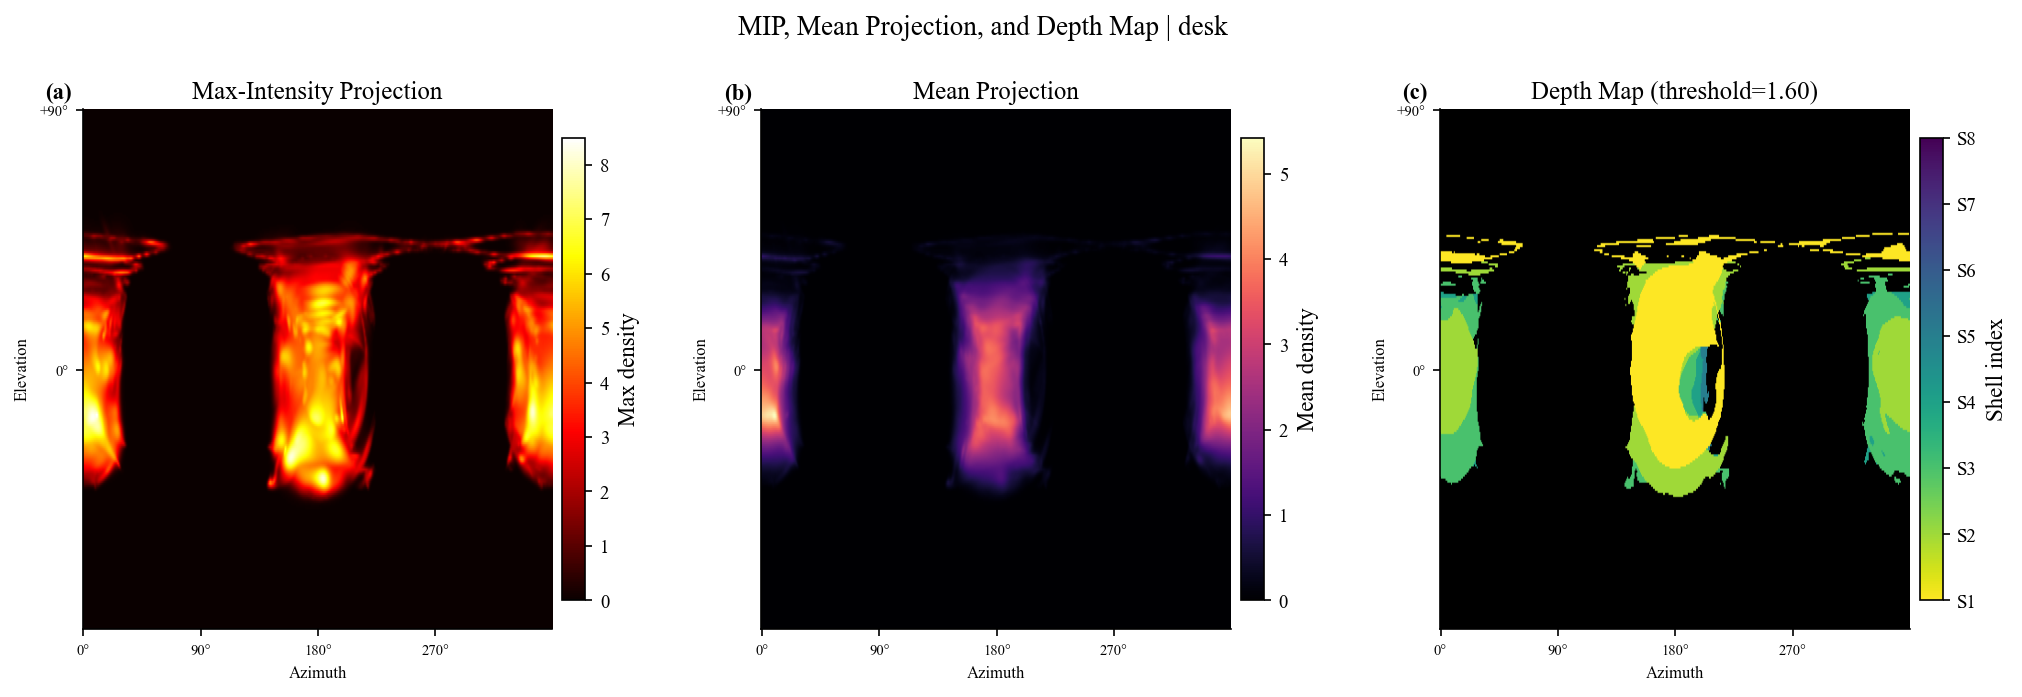

Depth coverage: 15.5% of pixels above threshold


In [27]:
mip = erp.max(axis=0)
mean_proj = erp.mean(axis=0)

threshold = erp.max() * 0.15
above = erp > threshold
depth_map = np.argmax(above, axis=0).astype(float)
depth_map[~above.any(axis=0)] = np.nan

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5),
                          gridspec_kw={'wspace': 0.35})

for ax in axes:
    ax.set_xticks(az_ticks); ax.set_xticklabels(az_labels, fontsize=7)
    ax.set_yticks(el_ticks); ax.set_yticklabels(el_labels, fontsize=7)
    ax.set_xlabel('Azimuth', fontsize=8)
    ax.set_ylabel('Elevation', fontsize=8)

im0 = axes[0].imshow(gaussian_filter(mip, 0.8), cmap='hot', aspect='auto')
axes[0].set_title('Max-Intensity Projection', pad=5)
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.02, label='Max density')
axes[0].text(-0.08, 1.05, '(a)', transform=axes[0].transAxes,
             fontsize=11, fontweight='bold', va='top')

im1 = axes[1].imshow(gaussian_filter(mean_proj, 0.8), cmap='magma', aspect='auto')
axes[1].set_title('Mean Projection', pad=5)
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.02, label='Mean density')
axes[1].text(-0.08, 1.05, '(b)', transform=axes[1].transAxes,
             fontsize=11, fontweight='bold', va='top')

cmap_depth = plt.cm.viridis_r.copy()
cmap_depth.set_bad('black', alpha=1.0)
im2 = axes[2].imshow(depth_map, cmap=cmap_depth, aspect='auto',
                     vmin=0, vmax=N_SHELLS - 1)
axes[2].set_title(f'Depth Map (threshold={threshold:.2f})', pad=5)
cbar2 = plt.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.02)
cbar2.set_label('Shell index')
cbar2.set_ticks(range(N_SHELLS))
cbar2.set_ticklabels([f'S{i+1}' for i in range(N_SHELLS)])
axes[2].text(-0.08, 1.05, '(c)', transform=axes[2].transAxes,
             fontsize=11, fontweight='bold', va='top')

fig.suptitle(f'MIP, Mean Projection, and Depth Map | {FOCUS_CLASS}', fontsize=13, y=1.02)
fig.savefig(FIG_DIR / '2_mip_depth.pdf', bbox_inches='tight')
plt.show()
print(f'Depth coverage: {(~np.isnan(depth_map)).mean()*100:.1f}% of pixels above threshold')

---
## Section 3 — Radial Depth Profile

For a fixed azimuth column, density vs shell index as a 2-D heatmap —
a side-view cross-section of the radial density field.

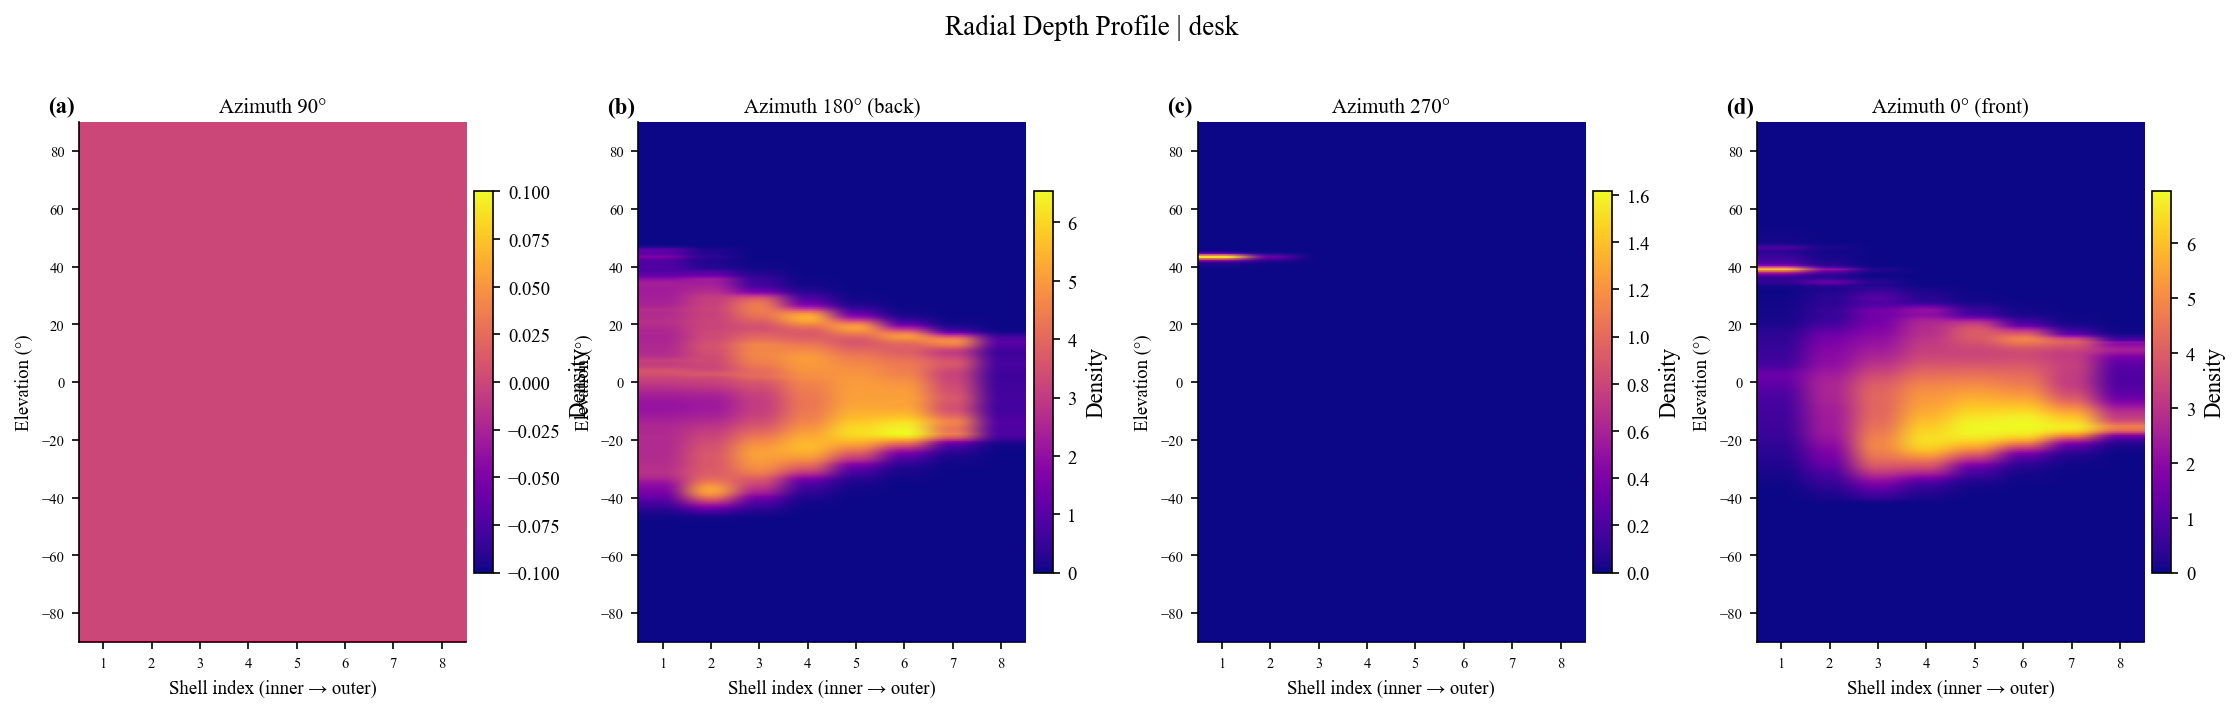

In [28]:
azimuths = [W // 4, W // 2, 3 * W // 4, 0]
az_plot_labels = ['90\u00b0', '180\u00b0 (back)', '270\u00b0', '0\u00b0 (front)']

fig, axes = plt.subplots(1, 4, figsize=(18, 4.5),
                          gridspec_kw={'wspace': 0.35})

for k, (ax, col, label) in enumerate(zip(axes, azimuths, az_plot_labels)):
    profile = erp[:, :, col]
    profile_smooth = gaussian_filter(profile.astype(np.float64), sigma=0.6)
    im = ax.imshow(
        profile_smooth.T, cmap='plasma', aspect='auto',
        extent=[0.5, N_SHELLS + 0.5, -90, 90], origin='upper',
    )
    ax.set_title(f'Azimuth {label}', fontsize=10, pad=5)
    ax.set_xlabel('Shell index (inner \u2192 outer)', fontsize=9)
    ax.set_ylabel('Elevation (\u00b0)', fontsize=9)
    ax.set_xticks(range(1, N_SHELLS + 1))
    ax.tick_params(labelsize=7)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.02, label='Density')
    ax.text(-0.08, 1.05, f'({"abcd"[k]})', transform=ax.transAxes,
            fontsize=11, fontweight='bold', va='top')

fig.suptitle(f'Radial Depth Profile | {FOCUS_CLASS}', fontsize=13, y=1.04)
fig.savefig(FIG_DIR / '3_radial_depth_profile.pdf', bbox_inches='tight')
plt.show()

---
## Section 4 — Polar Plot: azimuth-averaged radial density

Average density over all elevations for each azimuth column, plotted on
polar coordinates (radius = shell index, angle = azimuth).

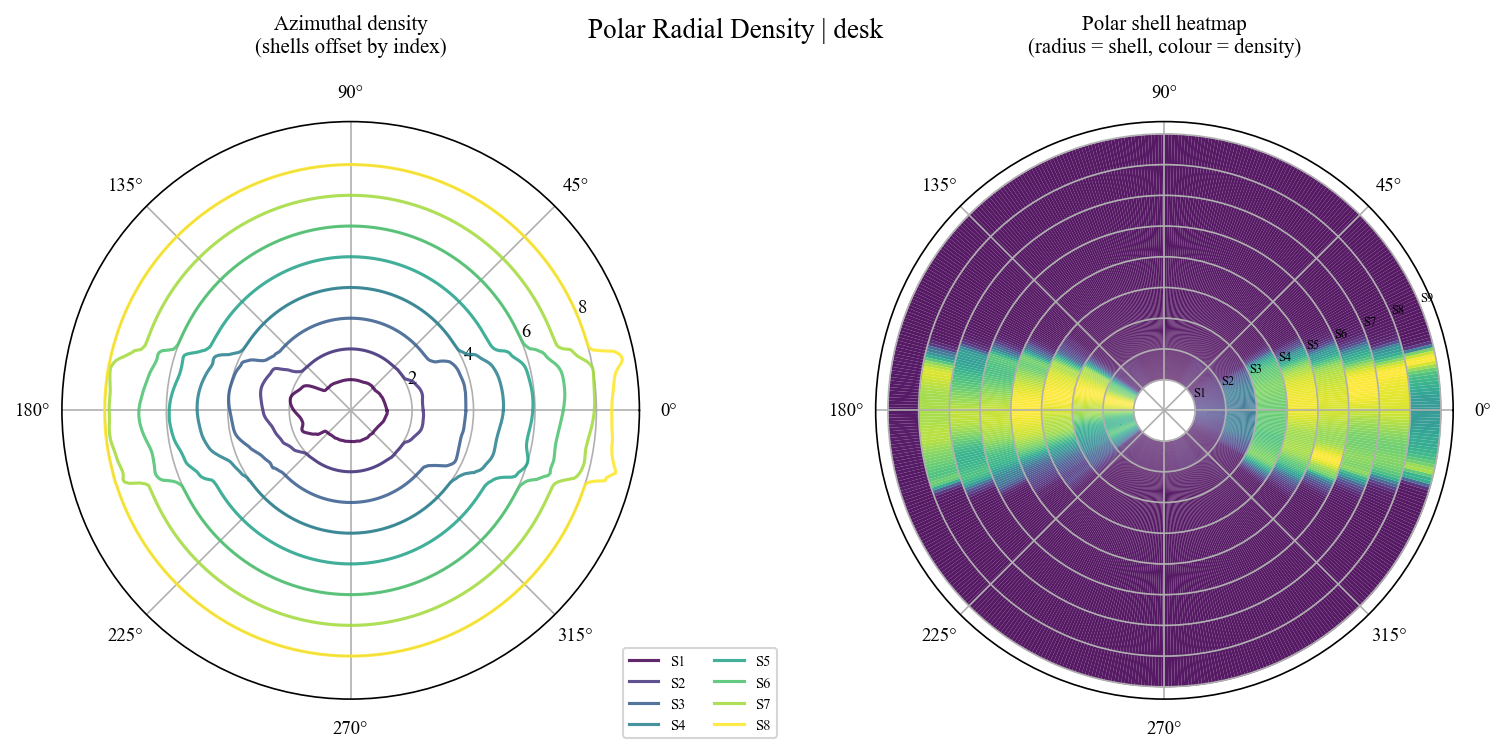

In [29]:
az_mean = erp.mean(axis=1)    # (N_shells, W)
theta = np.linspace(0, 2 * np.pi, W, endpoint=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 5),
                          subplot_kw={'projection': 'polar'},
                          gridspec_kw={'wspace': 0.4})

cmap_shells = plt.cm.viridis
norm_shells = mcolors.Normalize(vmin=1, vmax=N_SHELLS)

for s in range(N_SHELLS):
    rho = normalise(az_mean[s]) + s + 1
    axes[0].plot(theta, rho,
                 color=cmap_shells(norm_shells(s + 1)),
                 linewidth=1.5, alpha=0.85,
                 label=f'S{s+1}')

axes[0].set_title('Azimuthal density\n(shells offset by index)', pad=15, fontsize=10)
axes[0].legend(loc='lower right', bbox_to_anchor=(1.25, -0.08),
               fontsize=7, ncol=2)

# Polar heatmap
dtheta = 2 * np.pi / W
for s in range(N_SHELLS):
    rho_inner = s + 1
    rho_outer = s + 2
    vals = normalise(az_mean[s])
    for i in range(W):
        color = cmap_shells(vals[i])
        angles = [theta[i], theta[i] + dtheta]
        axes[1].fill_between(angles, rho_inner, rho_outer,
                             color=color, alpha=0.9, linewidth=0)

axes[1].set_yticks(range(1, N_SHELLS + 2))
axes[1].set_yticklabels([f'S{s}' for s in range(1, N_SHELLS + 2)], fontsize=6)
axes[1].set_title('Polar shell heatmap\n(radius = shell, colour = density)', pad=15, fontsize=10)

fig.suptitle(f'Polar Radial Density | {FOCUS_CLASS}', fontsize=13, y=1.02)
fig.savefig(FIG_DIR / '4_polar_density.pdf', bbox_inches='tight')
plt.show()

---
## Section 5 — Onion Cross-Section (meridian slice)

Slice the ERP at a fixed azimuth and show the density as concentric rings
on a 2-D cross-section plane. Inner rings correspond to inner shells.

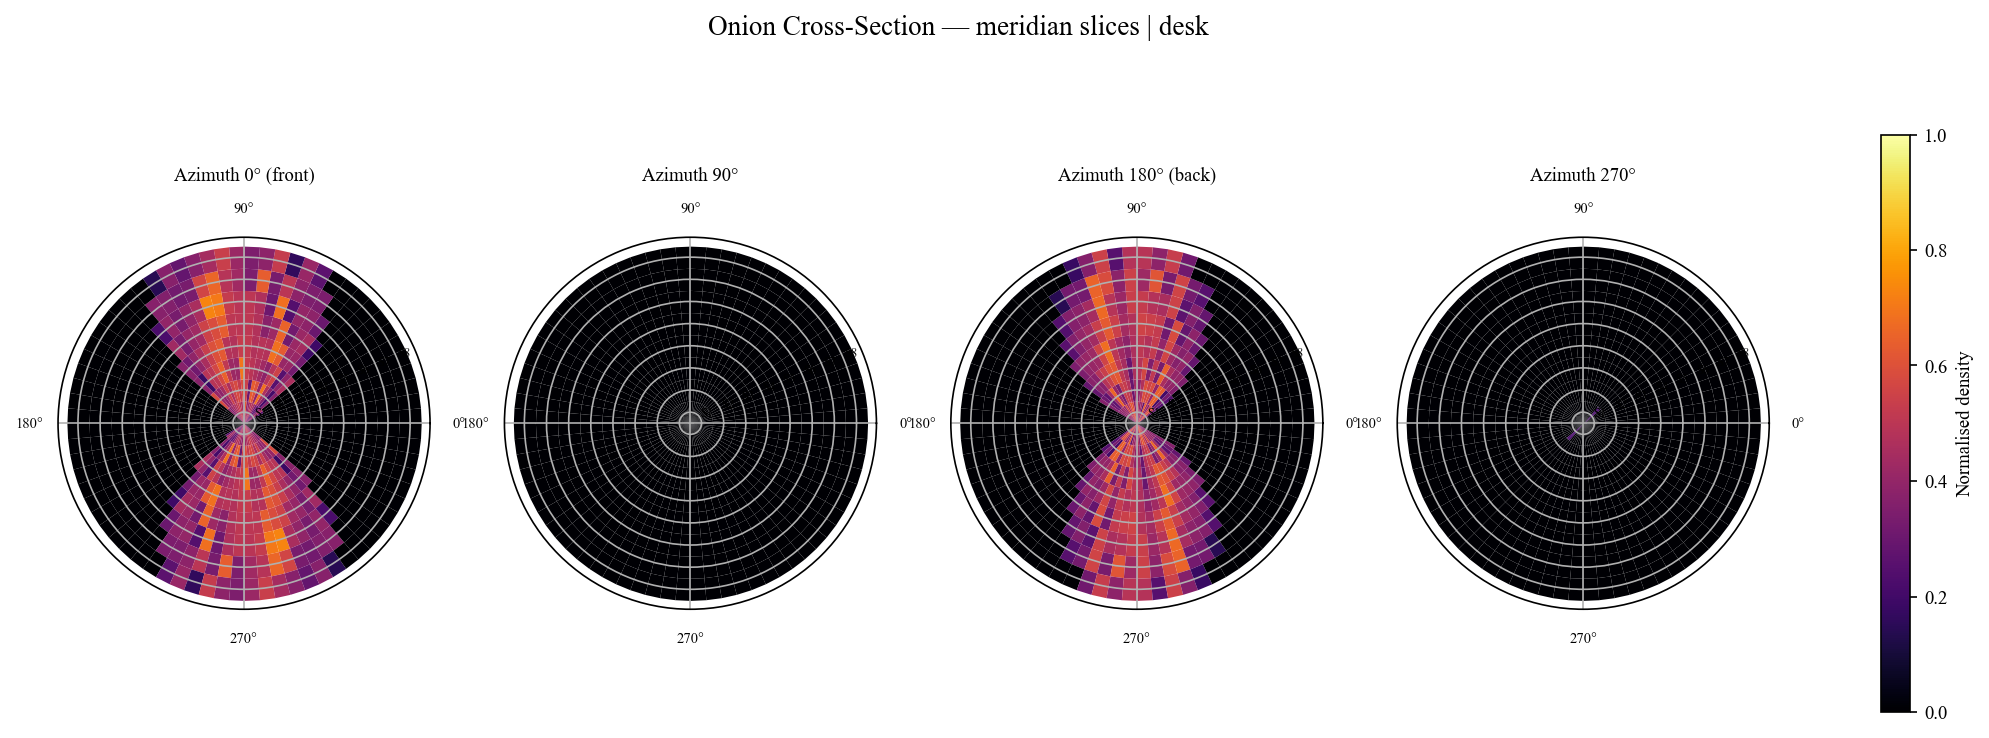

In [30]:
from matplotlib.patches import Wedge
from matplotlib.collections import PatchCollection

def onion_cross_section(erp_arr, az_col: int, n_elev_bins: int = 36, ax=None):
    if ax is None:
        _, ax = plt.subplots(subplot_kw={'projection': 'polar'})
    bins = np.array_split(np.arange(H), n_elev_bins)
    elev_angles = np.linspace(0, np.pi, n_elev_bins + 1)
    for s in range(N_SHELLS):
        r_inner = s / N_SHELLS
        r_outer = (s + 1) / N_SHELLS
        for e, (idx_group, a0, a1) in enumerate(
                zip(bins, elev_angles[:-1], elev_angles[1:])):
            val = normalise(erp_arr[s, idx_group, az_col]).mean()
            color = plt.cm.inferno(val)
            for theta_offset in (0, np.pi):
                ax.fill_between(
                    [a0 + theta_offset, a1 + theta_offset],
                    r_inner, r_outer, color=color, linewidth=0)
    ax.set_yticks([(s + 0.5) / N_SHELLS for s in range(N_SHELLS)])
    ax.set_yticklabels([f'S{s+1}' for s in range(N_SHELLS)], fontsize=6)
    ax.set_xticks(np.linspace(0, 2 * np.pi, 5)[:-1])
    ax.set_xticklabels(['0\u00b0', '90\u00b0', '180\u00b0', '270\u00b0'], fontsize=7)
    return ax

fig = plt.figure(figsize=(16, 5))
az_cols  = [0, W // 4, W // 2, 3 * W // 4]
az_names = ['0\u00b0 (front)', '90\u00b0', '180\u00b0 (back)', '270\u00b0']

for k, (col, name) in enumerate(zip(az_cols, az_names)):
    ax = fig.add_subplot(1, 4, k + 1, projection='polar')
    onion_cross_section(erp, az_col=col, ax=ax)
    ax.set_title(f'Azimuth {name}', fontsize=9, pad=10)

sm = plt.cm.ScalarMappable(cmap='inferno', norm=mcolors.Normalize(0, 1))
sm.set_array([])
cbar = fig.colorbar(sm, ax=fig.axes, fraction=0.02, pad=0.06)
cbar.set_label('Normalised density', fontsize=9)

fig.suptitle(
    f'Onion Cross-Section — meridian slices | {FOCUS_CLASS}',
    fontsize=13, y=1.04,
)
fig.savefig(FIG_DIR / '5_onion_cross_section.pdf', bbox_inches='tight')
plt.show()

---
## Section 6 — Per-Shell Statistics: violin and box plots

Distribution of raw density values at each shell.

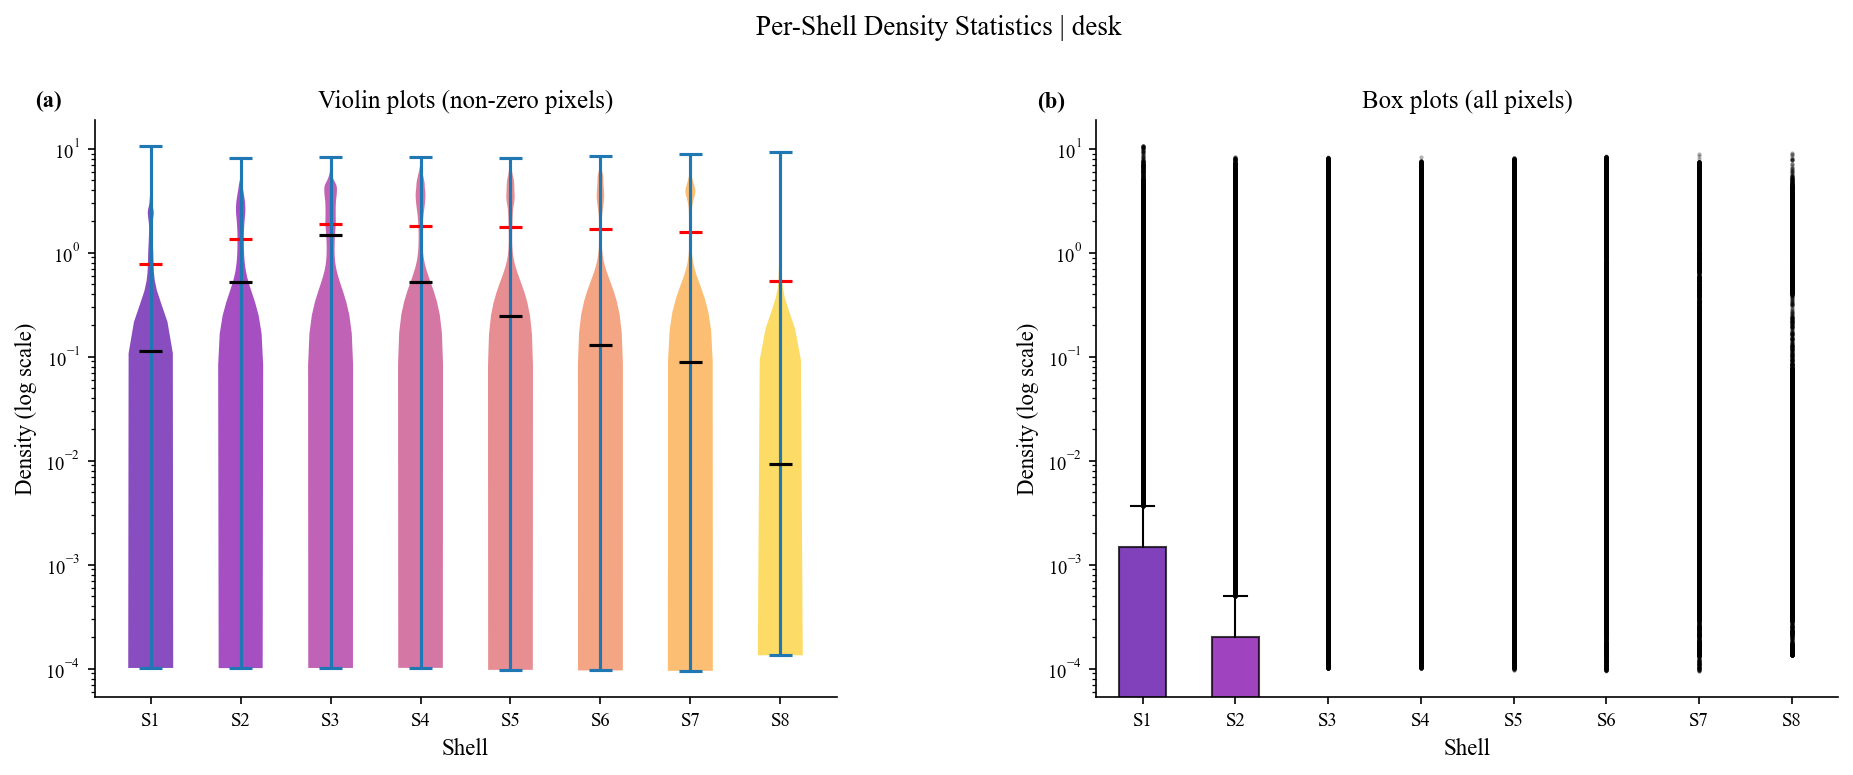

  Shell  |  mean      |  std       |  p50       |  p99
  ───────────────────────────────────────────────────────
  S1     |  0.228767  |  0.730372  |  0.000000  |  3.443604
  S2     |  0.349145  |  0.986080  |  0.000000  |  4.467321
  S3     |  0.446449  |  1.223164  |  0.000000  |  5.218046
  S4     |  0.383263  |  1.209380  |  0.000000  |  5.642558
  S5     |  0.308381  |  1.130895  |  0.000000  |  5.783485
  S6     |  0.233137  |  0.998420  |  0.000000  |  5.471134
  S7     |  0.161181  |  0.810425  |  0.000000  |  4.638885
  S8     |  0.031599  |  0.290172  |  0.000000  |  1.394210


In [31]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5), gridspec_kw={'wspace': 0.35})

# Left: violin plots (non-zero pixels)
violin_data = []
violin_labels = []
for s in range(N_SHELLS):
    vals = erp[s].ravel()
    vals_pos = vals[vals > 1e-6]
    if len(vals_pos) > 10000:
        vals_pos = np.random.default_rng(42).choice(vals_pos, 10000, replace=False)
    violin_data.append(vals_pos)
    violin_labels.append(f'S{s+1}')

parts = axes[0].violinplot(violin_data, positions=range(1, N_SHELLS + 1),
                           showmeans=True, showmedians=True)
for i, pc in enumerate(parts['bodies']):
    pc.set_facecolor(SHELL_COLORS[i])
    pc.set_alpha(0.7)
parts['cmeans'].set_color('red')
parts['cmedians'].set_color('black')

axes[0].set_yscale('log')
axes[0].set_xticks(range(1, N_SHELLS + 1))
axes[0].set_xticklabels(violin_labels)
axes[0].set_xlabel('Shell')
axes[0].set_ylabel('Density (log scale)')
axes[0].set_title('Violin plots (non-zero pixels)')
axes[0].text(-0.08, 1.05, '(a)', transform=axes[0].transAxes,
             fontsize=11, fontweight='bold', va='top')

# Right: box plots (all pixels)
data_bp = [erp[s].ravel() for s in range(N_SHELLS)]
bp = axes[1].boxplot(
    data_bp, patch_artist=True,
    medianprops=dict(color='black', linewidth=1.5),
    whiskerprops=dict(linewidth=1),
    flierprops=dict(marker='.', markersize=2, alpha=0.3),
)
for patch, color in zip(bp['boxes'], SHELL_COLORS):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)

axes[1].set_yscale('log')
axes[1].set_xticks(range(1, N_SHELLS + 1))
axes[1].set_xticklabels(violin_labels)
axes[1].set_xlabel('Shell')
axes[1].set_ylabel('Density (log scale)')
axes[1].set_title('Box plots (all pixels)')
axes[1].text(-0.08, 1.05, '(b)', transform=axes[1].transAxes,
             fontsize=11, fontweight='bold', va='top')

fig.suptitle(f'Per-Shell Density Statistics | {FOCUS_CLASS}', fontsize=13, y=1.02)
fig.savefig(FIG_DIR / '6_per_shell_stats.pdf', bbox_inches='tight')
plt.show()

print(f'  Shell  |  mean      |  std       |  p50       |  p99')
print(f'  {"\u2500"*55}')
for s in range(N_SHELLS):
    v = erp[s].ravel()
    print(f'  S{s+1:1d}     |  {v.mean():.6f}  |  {v.std():.6f}  |  '
          f'{np.percentile(v,50):.6f}  |  {np.percentile(v,99):.6f}')

---
## Section 7 — Inter-Shell Correlation Matrix

Pearson correlation between flattened shell density maps. High correlation
between adjacent shells is expected; low between inner and outer shells.

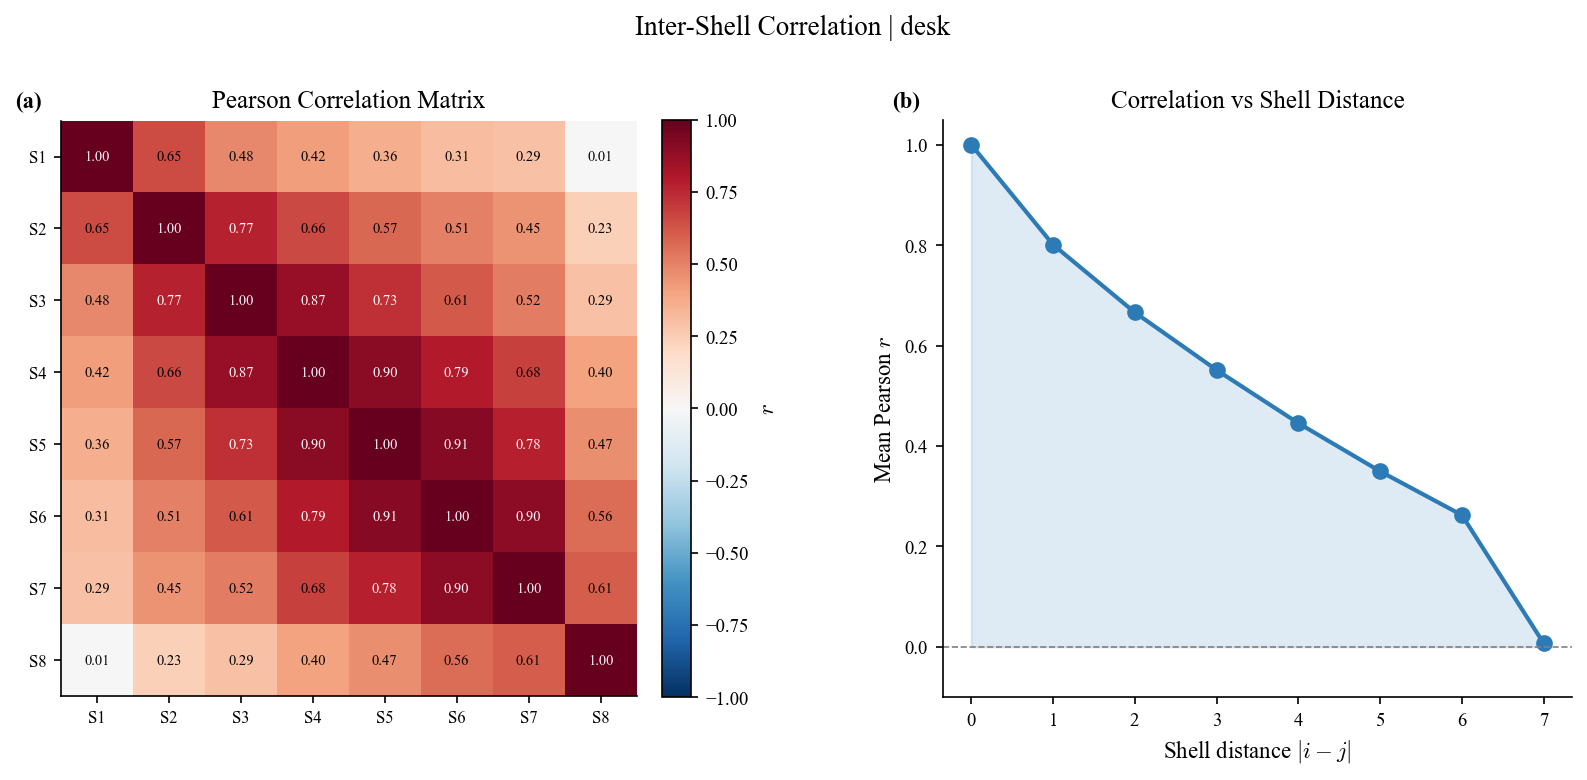

In [32]:
flat = erp.reshape(N_SHELLS, -1)
corr = np.corrcoef(flat)  # (N_SHELLS, N_SHELLS)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), gridspec_kw={'wspace': 0.4})

# Left: correlation matrix
ax = axes[0]
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1, aspect='equal')
for i in range(N_SHELLS):
    for j in range(N_SHELLS):
        ax.text(j, i, f'{corr[i,j]:.2f}', ha='center', va='center',
                fontsize=7, color='black' if abs(corr[i,j]) < 0.7 else 'white')
ax.set_xticks(range(N_SHELLS))
ax.set_yticks(range(N_SHELLS))
ax.set_xticklabels([f'S{s+1}' for s in range(N_SHELLS)], fontsize=8)
ax.set_yticklabels([f'S{s+1}' for s in range(N_SHELLS)], fontsize=8)
ax.set_title('Pearson Correlation Matrix')
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='$r$')
ax.text(-0.08, 1.05, '(a)', transform=ax.transAxes,
        fontsize=11, fontweight='bold', va='top')

# Right: correlation vs shell distance
ax = axes[1]
distances = np.arange(0, N_SHELLS)
mean_corr_by_dist = [
    np.mean([corr[i, j] for i in range(N_SHELLS)
             for j in range(N_SHELLS) if abs(i - j) == d])
    for d in distances
]
ax.plot(distances, mean_corr_by_dist, 'o-', color='#2c7bb6', linewidth=2, markersize=7)
ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
ax.fill_between(distances, mean_corr_by_dist, alpha=0.15, color='#2c7bb6')
ax.set_xlabel('Shell distance $|i - j|$')
ax.set_ylabel('Mean Pearson $r$')
ax.set_title('Correlation vs Shell Distance')
ax.set_xticks(distances)
ax.set_ylim(-0.1, 1.05)
ax.text(-0.08, 1.05, '(b)', transform=ax.transAxes,
        fontsize=11, fontweight='bold', va='top')

fig.suptitle(f'Inter-Shell Correlation | {FOCUS_CLASS}', fontsize=13, y=1.02)
fig.savefig(FIG_DIR / '7_shell_correlation.pdf', bbox_inches='tight')
plt.show()

---
## Section 8 — Cross-Class Radial Signatures

Mean density per shell for each class with \u00b11 std shaded bands.
Shows how different 3D object classes produce distinguishable radial
density distributions (e.g., solid vs hollow objects).

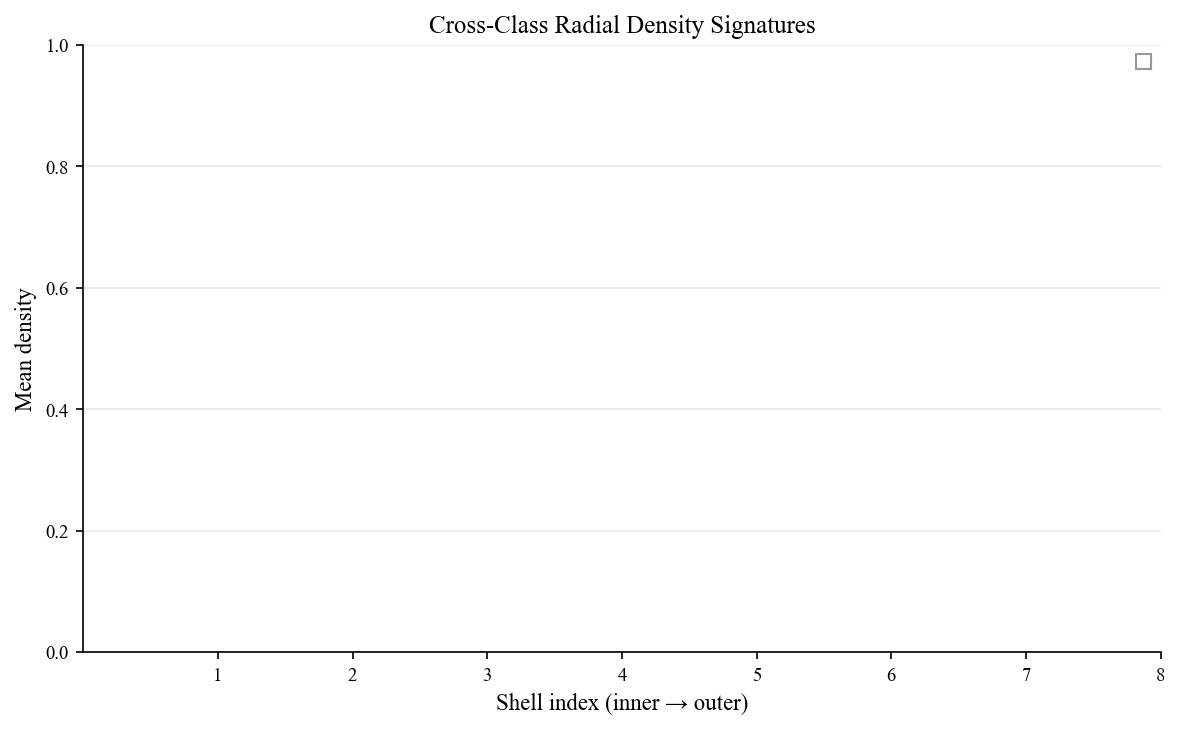

In [33]:
fig, ax = plt.subplots(figsize=(8, 5))

shell_idx = np.arange(1, N_SHELLS + 1)

for cls in STAT_CLASSES:
    profiles = class_shell_profiles[cls]  # (N, 8)
    mu = profiles.mean(axis=0)
    sigma = profiles.std(axis=0)
    ax.plot(shell_idx, mu, 'o-', color=CLASS_COLORS[cls], label=cls,
            linewidth=1.8, markersize=5)
    ax.fill_between(shell_idx, mu - sigma, mu + sigma,
                    color=CLASS_COLORS[cls], alpha=0.15)

ax.set_xlabel('Shell index (inner \u2192 outer)')
ax.set_ylabel('Mean density')
ax.set_title('Cross-Class Radial Density Signatures')
ax.set_xticks(shell_idx)
ax.legend(frameon=True, fancybox=False, edgecolor='gray')
ax.grid(axis='y', alpha=0.3)

fig.tight_layout()
fig.savefig(FIG_DIR / '8_radial_signatures.pdf', bbox_inches='tight')
plt.show()

---
## Section 9 — Latitude-Resolved Density with SWHDC Weights

Per-class mean density as a function of latitude, overlaid with the
SWHDC mixing weights $W_n(\phi)$ for dilation rates 1\u20134.
This figure justifies the SWHDC architecture: density concentrates near
the equator where the SWHDC weights transition between dilation rates.

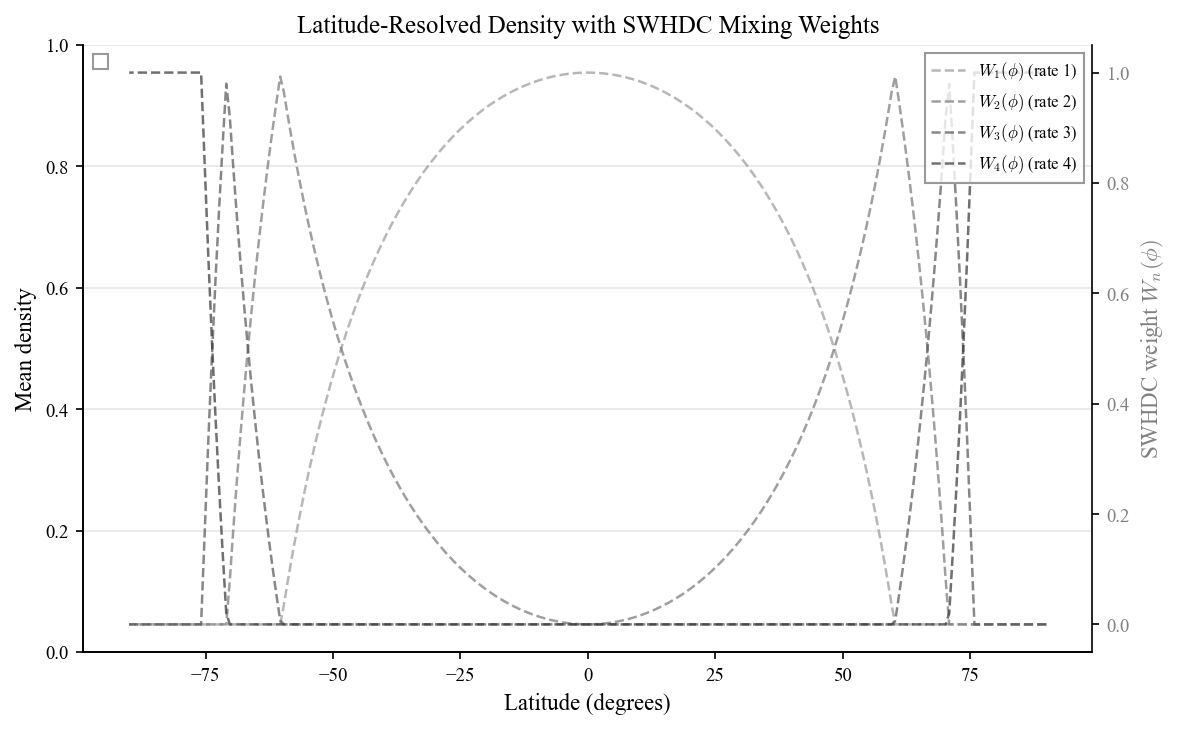

In [34]:
import torch
from src.models.blocks.swhdc import compute_swhdc_weights

latitudes = np.linspace(90, -90, H)

# Pick 4 representative classes
rep_classes = [c for c in ['bed', 'chair', 'monitor', 'sofa'] if c in STAT_CLASSES]
if len(rep_classes) < 3:
    rep_classes = STAT_CLASSES[:4]

fig, ax1 = plt.subplots(figsize=(8, 5))

for cls in rep_classes:
    lat_prof = class_lat_profiles[cls]  # (N, H)
    mu = lat_prof.mean(axis=0)
    ax1.plot(latitudes, mu, color=CLASS_COLORS[cls], linewidth=1.5, label=cls)

ax1.set_xlabel('Latitude (degrees)')
ax1.set_ylabel('Mean density', color='black')
ax1.legend(loc='upper left', frameon=True, fancybox=False, edgecolor='gray')
ax1.grid(axis='y', alpha=0.3)

# SWHDC weights on secondary axis
ax2 = ax1.twinx()
weights = compute_swhdc_weights(H, N=4).numpy()  # (4, H)
dilation_colors = ['#999999', '#777777', '#555555', '#333333']
for d in range(4):
    ax2.plot(latitudes, weights[d], linestyle='--', linewidth=1.2,
             color=dilation_colors[d], alpha=0.7,
             label=f'$W_{d+1}(\\phi)$ (rate {d+1})')

ax2.set_ylabel('SWHDC weight $W_n(\\phi)$', color='gray')
ax2.tick_params(axis='y', labelcolor='gray')
ax2.legend(loc='upper right', frameon=True, fancybox=False, edgecolor='gray',
           fontsize=8)
ax2.spines['right'].set_visible(True)

ax1.set_title('Latitude-Resolved Density with SWHDC Mixing Weights')
fig.tight_layout()
fig.savefig(FIG_DIR / '9_latitude_density_swhdc.pdf', bbox_inches='tight')
plt.show()

---
## Section 10 — Feature Embedding (PCA + t-SNE)

Each sample is reduced to a 48-dimensional feature vector (per-shell
mean, std, p25, p50, p75, sparsity), then projected to 2-D.
Shows class separability in the raw feature space before any learned model.

In [35]:
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Build feature matrix
X_list, y_list = [], []
for cls in STAT_CLASSES:
    feats = class_features[cls]  # (N, 48)
    X_list.append(feats)
    y_list.extend([cls] * len(feats))

X = StandardScaler().fit_transform(np.vstack(X_list))
y = np.array(y_list)

pca_2d  = PCA(n_components=2).fit_transform(X)
tsne_2d = TSNE(n_components=2, perplexity=30, random_state=42).fit_transform(X)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

for cls in STAT_CLASSES:
    mask = y == cls
    ax1.scatter(pca_2d[mask, 0], pca_2d[mask, 1], s=15, alpha=0.6,
               color=CLASS_COLORS[cls], label=cls)
    ax2.scatter(tsne_2d[mask, 0], tsne_2d[mask, 1], s=15, alpha=0.6,
               color=CLASS_COLORS[cls], label=cls)

ax1.set_title('PCA')
ax1.set_xlabel('PC 1')
ax1.set_ylabel('PC 2')
ax1.legend(fontsize=8, markerscale=2, frameon=True, fancybox=False, edgecolor='gray')
ax1.text(-0.08, 1.05, '(a)', transform=ax1.transAxes,
         fontsize=11, fontweight='bold', va='top')

ax2.set_title('t-SNE')
ax2.set_xlabel('t-SNE 1')
ax2.set_ylabel('t-SNE 2')
ax2.legend(fontsize=8, markerscale=2, frameon=True, fancybox=False, edgecolor='gray')
ax2.text(-0.08, 1.05, '(b)', transform=ax2.transAxes,
         fontsize=11, fontweight='bold', va='top')

fig.suptitle('Shell Feature Embedding \u2014 PCA and t-SNE', fontsize=13, y=1.02)
fig.tight_layout()
fig.savefig(FIG_DIR / '10_embedding_pca_tsne.pdf', bbox_inches='tight')
plt.show()
print(f'Total samples: {len(y)}, classes: {len(STAT_CLASSES)}')

ValueError: need at least one array to concatenate

---
## Section 11 — Class-Average Shell Montage

Per-pixel mean density across all training samples for selected shells.
Each row is a class; each column is a shell. Averaged patterns reveal
structural archetypes (visual fingerprints) per class.

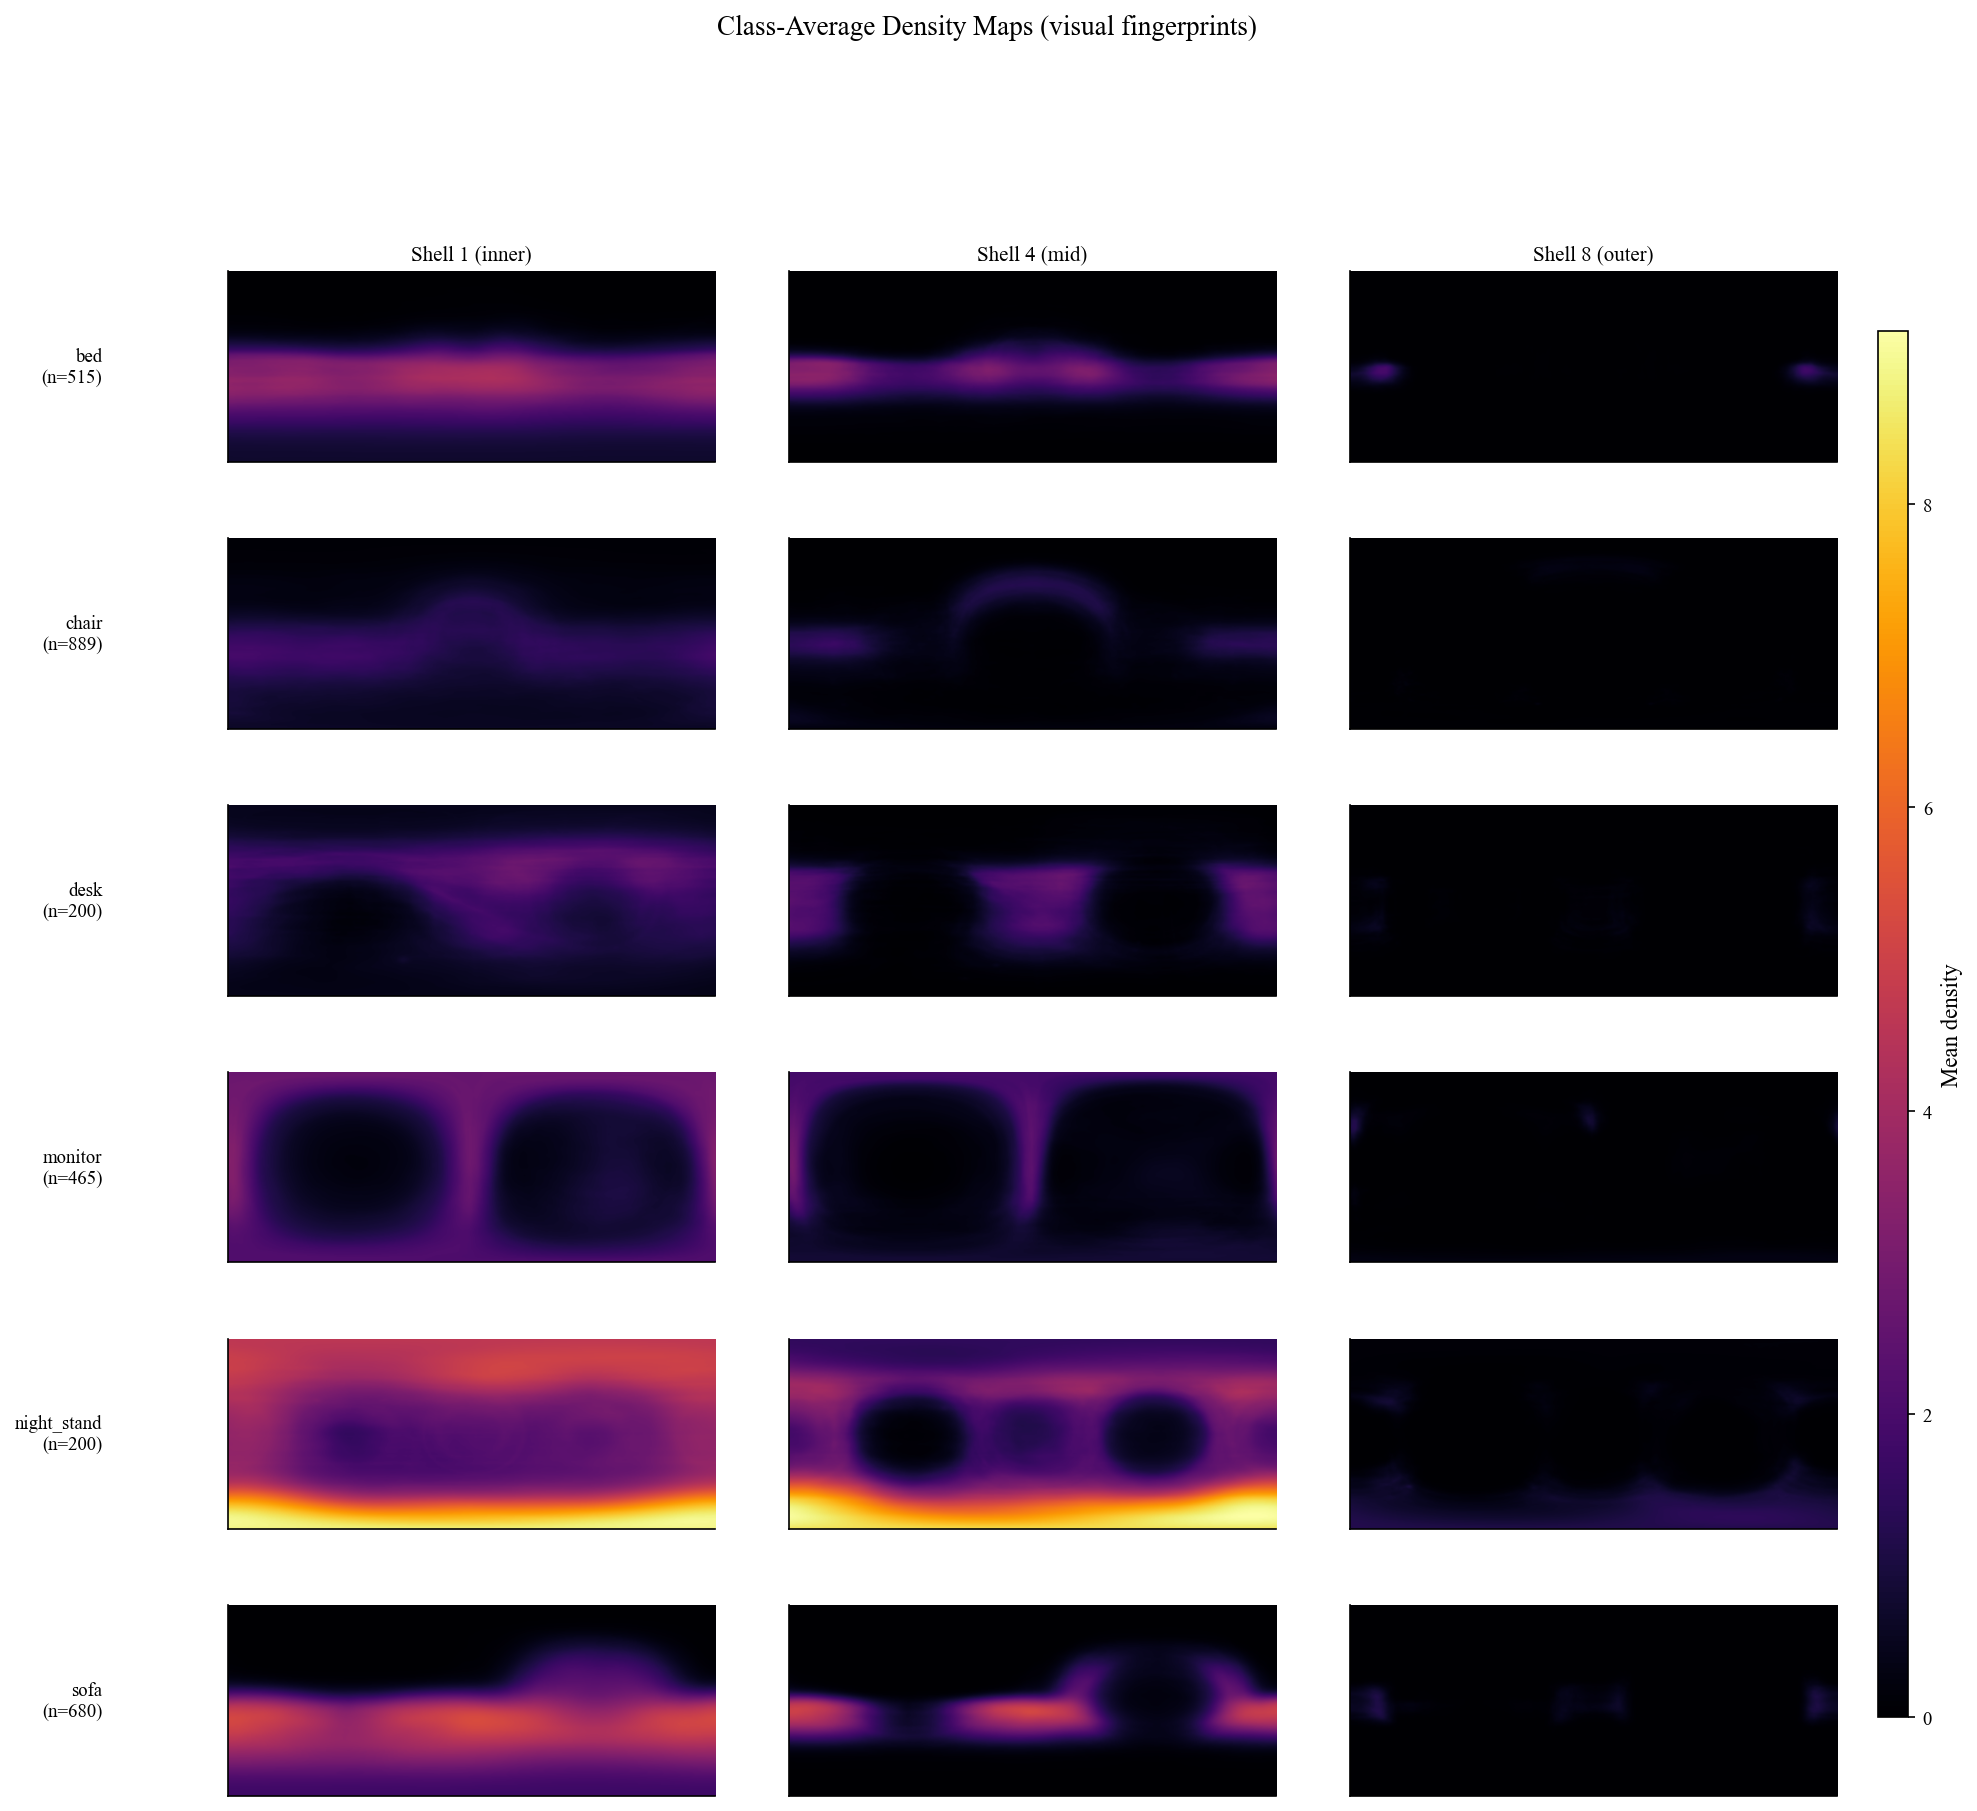

In [ ]:
show_shells = [0, 3, 7]  # shells 1, 4, 8
show_shell_names = ['Shell 1 (inner)', 'Shell 4 (mid)', 'Shell 8 (outer)']
avail_classes = [cls for cls in ALL_CLASSES if cls in class_shell_profiles]
n_cls = len(avail_classes)
n_cols = len(show_shells)

# Compute all means first to get global vmax
mean_maps = {}  # (cls, shell_idx) -> (H, W)
for cls in avail_classes:
    erps_cls = load_class_erps(cls, 'train')
    stack = np.array(erps_cls)  # (N, 8, H, W)
    for si in show_shells:
        mean_maps[(cls, si)] = gaussian_filter(stack[:, si].mean(axis=0), sigma=0.8)

global_vmax = max(v.max() for v in mean_maps.values())

fig, axes = plt.subplots(n_cls, n_cols, figsize=(4.5 * n_cols, 2.2 * n_cls),
                          gridspec_kw={'hspace': 0.4, 'wspace': 0.15})
if n_cls == 1:
    axes = axes[np.newaxis, :]

for r, cls in enumerate(avail_classes):
    n_samples = len(list_npys(cls, 'train'))
    for c, si in enumerate(show_shells):
        ax = axes[r, c]
        im = ax.imshow(mean_maps[(cls, si)], cmap='inferno', aspect='auto',
                       vmin=0, vmax=global_vmax, interpolation='bilinear')
        if c == 0:
            ax.set_ylabel(f'{cls}\n(n={n_samples})', fontsize=9, rotation=0,
                          labelpad=60, ha='right', va='center')
        if r == 0:
            ax.set_title(show_shell_names[c], fontsize=10)
        ax.set_xticks([])
        ax.set_yticks([])

fig.subplots_adjust(right=0.92)
cbar_ax = fig.add_axes([0.94, 0.15, 0.015, 0.7])
fig.colorbar(im, cax=cbar_ax, label='Mean density')

fig.suptitle('Class-Average Density Maps (visual fingerprints)', fontsize=13, y=1.01)
fig.savefig(FIG_DIR / '11_class_mean_montage.pdf', bbox_inches='tight')
plt.show()

---
## Section 12 — Sparsity and Energy Distribution

**Left:** Violin plots of sparsity ratio (fraction of near-zero pixels)
per shell, pooled across all classes.
**Right:** Stacked bars showing how each class distributes total density
mass across shells.

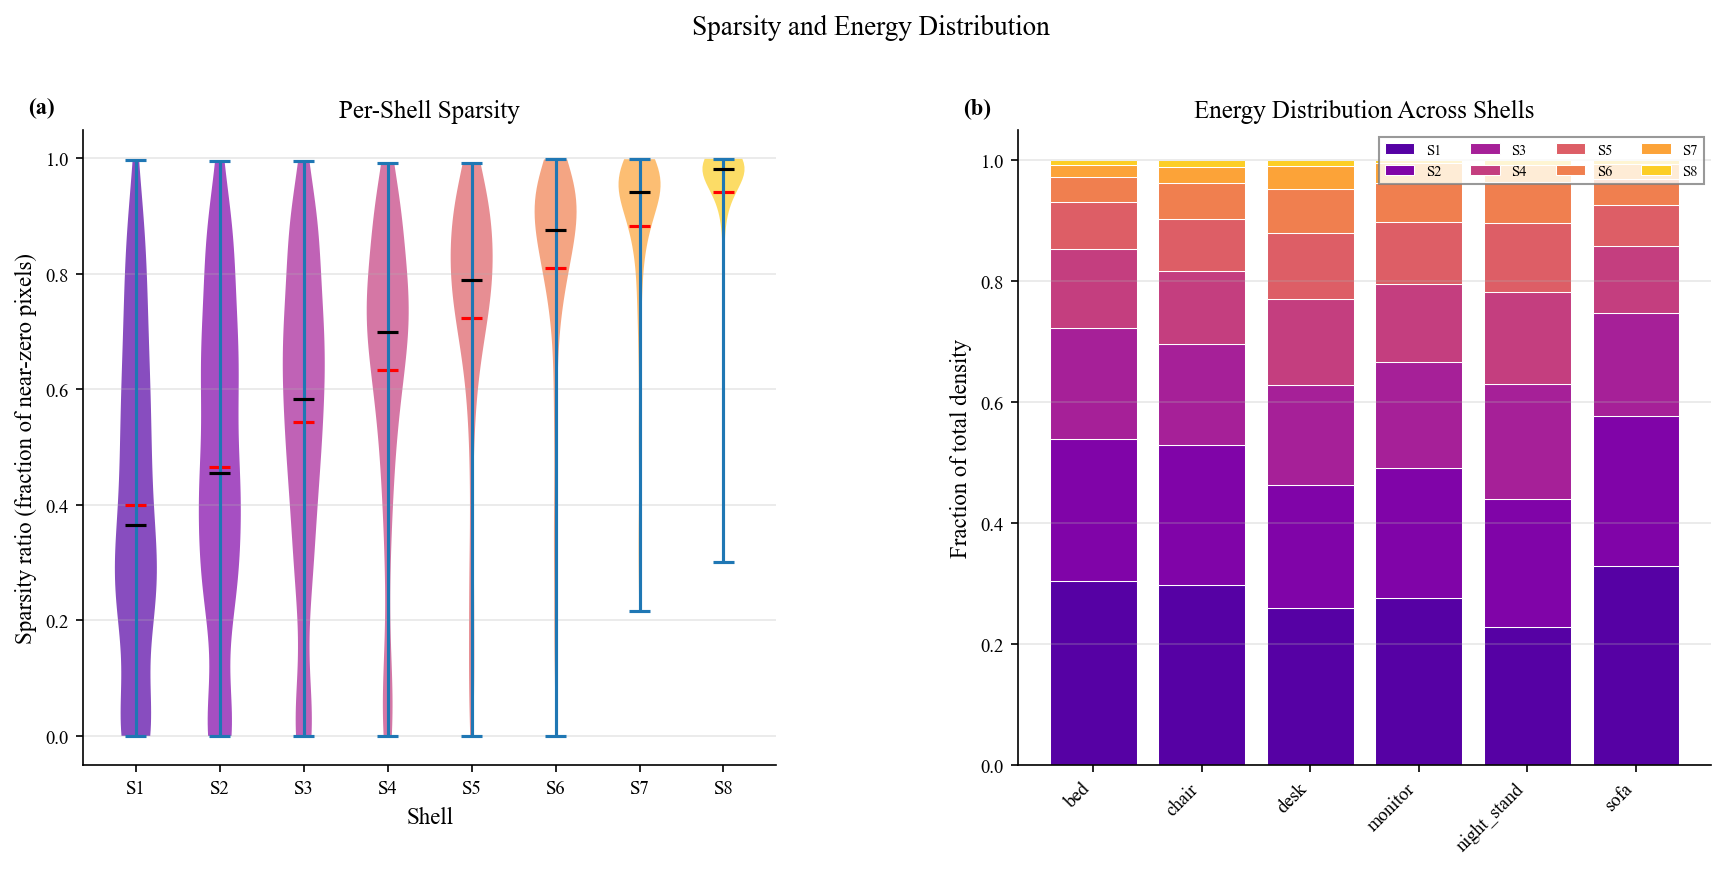

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5),
                                gridspec_kw={'wspace': 0.35})

# Left: sparsity violin plots
sparsity_per_shell = {s: [] for s in range(N_SHELLS)}
for cls in STAT_CLASSES:
    sp = class_sparsity[cls]  # (N, 8)
    for s in range(N_SHELLS):
        sparsity_per_shell[s].extend(sp[:, s].tolist())

violin_sp = [sparsity_per_shell[s] for s in range(N_SHELLS)]
parts = ax1.violinplot(violin_sp, positions=range(1, N_SHELLS + 1),
                       showmeans=True, showmedians=True)
for i, pc in enumerate(parts['bodies']):
    pc.set_facecolor(SHELL_COLORS[i])
    pc.set_alpha(0.7)
parts['cmeans'].set_color('red')
parts['cmedians'].set_color('black')

ax1.set_xticks(range(1, N_SHELLS + 1))
ax1.set_xticklabels([f'S{s+1}' for s in range(N_SHELLS)])
ax1.set_xlabel('Shell')
ax1.set_ylabel('Sparsity ratio (fraction of near-zero pixels)')
ax1.set_title('Per-Shell Sparsity')
ax1.set_ylim(-0.05, 1.05)
ax1.grid(axis='y', alpha=0.3)
ax1.text(-0.08, 1.05, '(a)', transform=ax1.transAxes,
         fontsize=11, fontweight='bold', va='top')

# Right: stacked energy bars
x_pos = np.arange(len(STAT_CLASSES))
bottoms = np.zeros(len(STAT_CLASSES))

for s in range(N_SHELLS):
    fracs = [class_energy_frac[cls][:, s].mean() for cls in STAT_CLASSES]
    ax2.bar(x_pos, fracs, bottom=bottoms, color=SHELL_COLORS[s],
            label=f'S{s+1}', edgecolor='white', linewidth=0.5)
    bottoms += fracs

ax2.set_xticks(x_pos)
ax2.set_xticklabels(STAT_CLASSES, rotation=45, ha='right')
ax2.set_ylabel('Fraction of total density')
ax2.set_title('Energy Distribution Across Shells')
ax2.legend(fontsize=7, ncol=4, loc='upper right',
           frameon=True, fancybox=False, edgecolor='gray')
ax2.set_ylim(0, 1.05)
ax2.grid(axis='y', alpha=0.3)
ax2.text(-0.08, 1.05, '(b)', transform=ax2.transAxes,
         fontsize=11, fontweight='bold', va='top')

fig.suptitle('Sparsity and Energy Distribution', fontsize=13, y=1.02)
fig.tight_layout()
fig.savefig(FIG_DIR / '12_sparsity_energy.pdf', bbox_inches='tight')
plt.show()

---
## All figures saved

In [ ]:
pdfs = sorted(FIG_DIR.glob('*.pdf'))
print(f'{len(pdfs)} figures saved to {FIG_DIR}:')
for p in pdfs:
    print(f'  {p.name}')

24 figures saved to C:\DEV_ENV\source\UFRGS\TCC\gs-erp-3d-classification\experiments\figures\erp_viz:
  10_embedding_pca_tsne.pdf
  10_extra_airplane.pdf
  10_extra_car.pdf
  10_extra_flower_pot.pdf
  10_intraclass_variation.pdf
  11_class_mean_montage.pdf
  12_sparsity_energy.pdf
  1_shell_strip.pdf
  2_mip_depth.pdf
  2_rgb_composite.pdf
  3_mip_depth.pdf
  3_radial_depth_profile.pdf
  4_polar_density.pdf
  4_radial_depth_profile.pdf
  5_onion_cross_section.pdf
  5_polar_density.pdf
  6_onion_cross_section.pdf
  6_per_shell_stats.pdf
  7_per_shell_stats.pdf
  7_shell_correlation.pdf
  8_radial_signatures.pdf
  8_shell_correlation.pdf
  9_class_gallery.pdf
  9_latitude_density_swhdc.pdf
